# 01 Data Exploration

This notebook performs exploratory data analysis (EDA) on the ISIC 2020 Training Ground Truth dataset for our Vision AI final project on melanoma detection.

## Goals

We will examine:

- dataset shape and structure
- missing values
- age statistics
- sex distribution
- benign vs malignant distribution
- diagnosis distribution
- anatomical site distribution
- target distribution by metadata
- patient-level image counts
- potential data leakage considerations for train/test splitting

This analysis helps guide preprocessing, feature selection, and model design decisions for melanoma classification.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
# Load the ISIC 2020 ground truth CSV
df = pd.read_csv("../data/ISIC_2020_Training_GroundTruth.csv")

# Preview
df.head()

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,female,55.0,upper extremity,unknown,benign,0


In [17]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape: (33126, 8)

Columns:
['image_name', 'patient_id', 'sex', 'age_approx', 'anatom_site_general_challenge', 'diagnosis', 'benign_malignant', 'target']

Data Types:
image_name                        object
patient_id                        object
sex                               object
age_approx                       float64
anatom_site_general_challenge     object
diagnosis                         object
benign_malignant                  object
target                             int64
dtype: object


In [18]:
total_rows, total_cols = df.shape

print("General Dataset Statistics")
print("==========================")
print(f"Total rows: {total_rows:,}")
print(f"Total columns: {total_cols}")
print(f"Unique patients: {df['patient_id'].nunique():,}")

General Dataset Statistics
Total rows: 33,126
Total columns: 8
Unique patients: 2,056


In [19]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().sum() / len(df)) * 100
}).sort_values("missing_count", ascending=False)

missing_summary

,missing_count,missing_percent
anatom_site_general_challenge,527,1.590895
age_approx,68,0.205277
sex,65,0.196220
image_name,0,0.000000
patient_id,0,0.000000
diagnosis,0,0.000000
benign_malignant,0,0.000000
target,0,0.000000


In [20]:
age_col = df["age_approx"]

print("Age (age_approx)")
print("================")
print(f"Non-missing: {age_col.notna().sum():,}")
print(f"Missing: {age_col.isna().sum():,}")
print(f"Mean: {age_col.mean():.2f}")
print(f"Standard deviation: {age_col.std():.2f}")
print(f"Median: {age_col.median():.0f}")
print(f"Min: {age_col.min():.0f}")
print(f"Max: {age_col.max():.0f}")

Age (age_approx)
Non-missing: 33,058
Missing: 68
Mean: 48.87
Standard deviation: 14.38
Median: 50
Min: 0
Max: 90


In [21]:
sex_counts = df["sex"].value_counts(dropna=False)
sex_percent = df["sex"].value_counts(dropna=False, normalize=True) * 100

print("Sex Distribution")
print("================")
for category, count in sex_counts.items():
    label = "Missing" if pd.isna(category) else category.capitalize()
    print(f"{label}: {count:,} ({sex_percent[category]:.2f}%)")

Sex Distribution
Male: 17,080 (51.56%)
Female: 15,981 (48.24%)
Missing: 65 (0.20%)


In [22]:
bm_counts = df["benign_malignant"].value_counts(dropna=False)
bm_percent = df["benign_malignant"].value_counts(dropna=False, normalize=True) * 100

print("Benign vs Malignant")
print("===================")
print("This dataset is highly imbalanced.\n")

for category, count in bm_counts.items():
    label = "Missing" if pd.isna(category) else category.capitalize()
    print(f"{label}: {count:,} ({bm_percent[category]:.2f}%)")

Benign vs Malignant
This dataset is highly imbalanced.

Benign: 32,542 (98.24%)
Malignant: 584 (1.76%)


In [23]:
diagnosis_counts = df["diagnosis"].value_counts(dropna=False)
diagnosis_percent = df["diagnosis"].value_counts(dropna=False, normalize=True) * 100

print("Diagnosis Distribution")
print("======================")
for category, count in diagnosis_counts.items():
    label = "Missing" if pd.isna(category) else category
    print(f"{label}: {count:,} ({diagnosis_percent[category]:.2f}%)")

Diagnosis Distribution
unknown: 27,124 (81.88%)
nevus: 5,193 (15.68%)
melanoma: 584 (1.76%)
seborrheic keratosis: 135 (0.41%)
lentigo NOS: 44 (0.13%)
lichenoid keratosis: 37 (0.11%)
solar lentigo: 7 (0.02%)
cafe-au-lait macule: 1 (0.00%)
atypical melanocytic proliferation: 1 (0.00%)


In [24]:
site_counts = df["anatom_site_general_challenge"].value_counts(dropna=False)
site_percent = df["anatom_site_general_challenge"].value_counts(dropna=False, normalize=True) * 100

print("Anatomical Site Distribution")
print("============================")
for category, count in site_counts.items():
    label = "Missing" if pd.isna(category) else category
    print(f"{label}: {count:,} ({site_percent[category]:.2f}%)")

Anatomical Site Distribution
torso: 16,845 (50.85%)
lower extremity: 8,417 (25.41%)
upper extremity: 4,983 (15.04%)
head/neck: 1,855 (5.60%)
Missing: 527 (1.59%)
palms/soles: 375 (1.13%)
oral/genital: 124 (0.37%)


In [25]:
def frequency_table(series, column_name="category"):
    counts = series.value_counts(dropna=False)
    percents = series.value_counts(dropna=False, normalize=True) * 100
    
    table = pd.DataFrame({
        column_name: counts.index,
        "count": counts.values,
        "percent": percents.values
    })
    
    table[column_name] = table[column_name].astype(object)
    table[column_name] = table[column_name].where(~table[column_name].isna(), "Missing")
    table["percent"] = table["percent"].round(2)
    return table

In [26]:
sex_table = frequency_table(df["sex"], "sex")
bm_table = frequency_table(df["benign_malignant"], "benign_malignant")
diagnosis_table = frequency_table(df["diagnosis"], "diagnosis")
site_table = frequency_table(df["anatom_site_general_challenge"], "anatomical_site")

print("Sex Table")
display(sex_table)

print("Benign / Malignant Table")
display(bm_table)

print("Diagnosis Table")
display(diagnosis_table)

print("Anatomical Site Table")
display(site_table)

Sex Table


,sex,count,percent
0,male,17080,51.56
1,female,15981,48.24
2,Missing,65,0.20


Benign / Malignant Table


,benign_malignant,count,percent
0,benign,32542,98.24
1,malignant,584,1.76


Diagnosis Table


,diagnosis,count,percent
0,unknown,27124,81.88
1,nevus,5193,15.68
2,melanoma,584,1.76
3,seborrheic keratosis,135,0.41
4,lentigo NOS,44,0.13
5,lichenoid keratosis,37,0.11
6,solar lentigo,7,0.02
7,cafe-au-lait macule,1,0.00
8,atypical melanocytic proliferation,1,0.00


Anatomical Site Table


,anatomical_site,count,percent
0,torso,16845,50.85
1,lower extremity,8417,25.41
2,upper extremity,4983,15.04
3,head/neck,1855,5.60
4,Missing,527,1.59
5,palms/soles,375,1.13
6,oral/genital,124,0.37


In [27]:
age_by_class = df.groupby("benign_malignant")["age_approx"].describe()
age_by_class

,count,mean,std,min,25%,50%,75%,max
benign_malignant,,,,,,,,
benign,32474.0,48.703424,14.290930,0.0,40.0,50.0,60.0,90.0
malignant,584.0,58.133562,16.200692,15.0,45.0,60.0,70.0,90.0


In [28]:
df["age_bin"] = pd.cut(
    df["age_approx"],
    bins=[0, 20, 40, 60, 80, 100],
    include_lowest=True
)

age_bin_target = pd.crosstab(df["age_bin"], df["target"], normalize="index") * 100
age_bin_target = age_bin_target.rename(columns={0: "Benign %", 1: "Malignant %"})

age_bin_target

target,Benign %,Malignant %
age_bin,,
"(-0.001, 20.0]",99.007444,0.992556
"(20.0, 40.0]",99.138265,0.861735
"(40.0, 60.0]",98.506329,1.493671
"(60.0, 80.0]",96.166243,3.833757
"(80.0, 100.0]",89.082969,10.917031


In [29]:
sex_target = pd.crosstab(df["sex"], df["target"], normalize="index") * 100
sex_target = sex_target.rename(columns={0: "Benign %", 1: "Malignant %"})
sex_target

target,Benign %,Malignant %
sex,,
female,98.623365,1.376635
male,97.868852,2.131148


In [30]:
site_target = pd.crosstab(df["anatom_site_general_challenge"], df["target"], normalize="index") * 100
site_target = site_target.rename(columns={0: "Benign %", 1: "Malignant %"})
site_target.sort_values("Malignant %", ascending=False)

target,Benign %,Malignant %
anatom_site_general_challenge,,
head/neck,96.010782,3.989218
oral/genital,96.774194,3.225806
upper extremity,97.772426,2.227574
torso,98.474325,1.525675
lower extremity,98.526791,1.473209
palms/soles,98.666667,1.333333


In [31]:
diagnosis_target = pd.crosstab(df["diagnosis"], df["target"])
diagnosis_target = diagnosis_target.rename(columns={0: "Benign Count", 1: "Malignant Count"})
diagnosis_target

target,Benign Count,Malignant Count
diagnosis,,
atypical melanocytic proliferation,1,0
cafe-au-lait macule,1,0
lentigo NOS,44,0
lichenoid keratosis,37,0
melanoma,0,584
nevus,5193,0
seborrheic keratosis,135,0
solar lentigo,7,0
unknown,27124,0


In [32]:
for col in ["sex", "age_approx", "anatom_site_general_challenge"]:
    print(f"\nMissing Analysis for {col}")
    display(pd.crosstab(df[col].isna(), df["target"], margins=True))


Missing Analysis for sex


target,0,1,All
sex,,,
False,32477,584,33061
True,65,0,65
All,32542,584,33126



Missing Analysis for age_approx


target,0,1,All
age_approx,,,
False,32474,584,33058
True,68,0,68
All,32542,584,33126



Missing Analysis for anatom_site_general_challenge


target,0,1,All
anatom_site_general_challenge,,,
False,32024,575,32599
True,518,9,527
All,32542,584,33126


In [33]:
images_per_patient = df.groupby("patient_id").size()

print("Images Per Patient Summary")
print("==========================")
print(images_per_patient.describe())

Images Per Patient Summary
count    2056.000000
mean       16.111868
std        15.674491
min         2.000000
25%         5.000000
50%        12.000000
75%        22.000000
max       115.000000
dtype: float64


In [34]:
patient_target_counts = df.groupby("patient_id")["target"].nunique()
patients_with_both_classes = (patient_target_counts > 1).sum()

print("Patients with both benign and malignant lesions:")
print(patients_with_both_classes)

Patients with both benign and malignant lesions:
427


In [35]:
benign_count = (df["target"] == 0).sum()
malignant_count = (df["target"] == 1).sum()

print("Imbalance Ratio")
print("===============")
print(f"Benign count: {benign_count:,}")
print(f"Malignant count: {malignant_count:,}")
print(f"Benign : Malignant ratio = {benign_count / malignant_count:.2f} : 1")

Imbalance Ratio
Benign count: 32,542
Malignant count: 584
Benign : Malignant ratio = 55.72 : 1


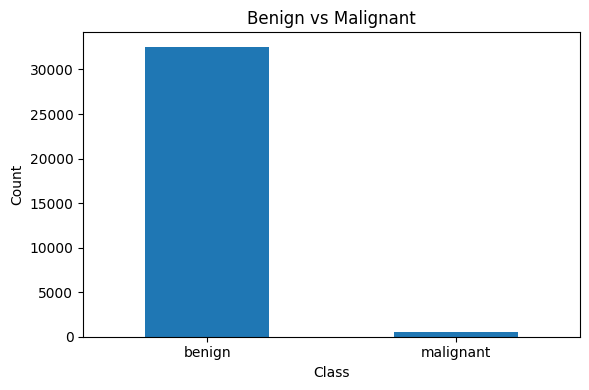

In [36]:
plt.figure(figsize=(6, 4))
df["benign_malignant"].value_counts().plot(kind="bar")
plt.title("Benign vs Malignant")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

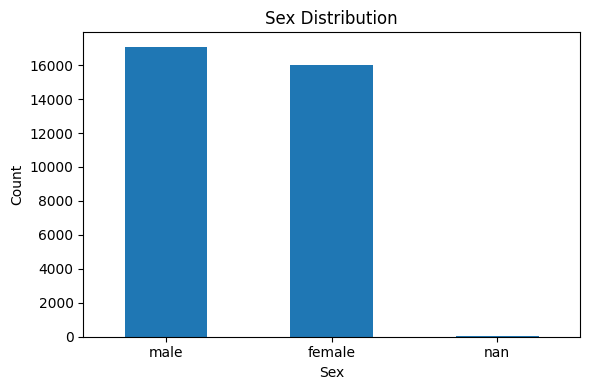

In [37]:
plt.figure(figsize=(6, 4))
df["sex"].value_counts(dropna=False).plot(kind="bar")
plt.title("Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

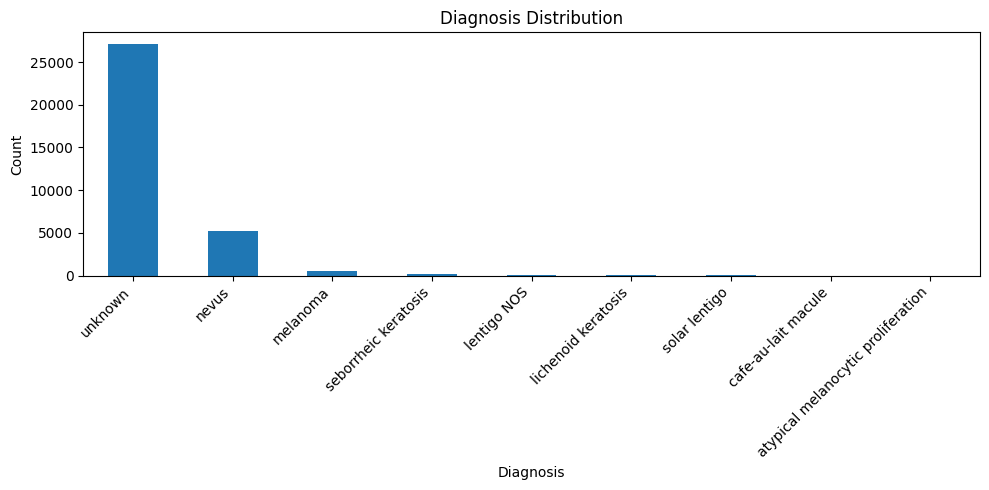

In [38]:
plt.figure(figsize=(10, 5))
df["diagnosis"].value_counts().plot(kind="bar")
plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

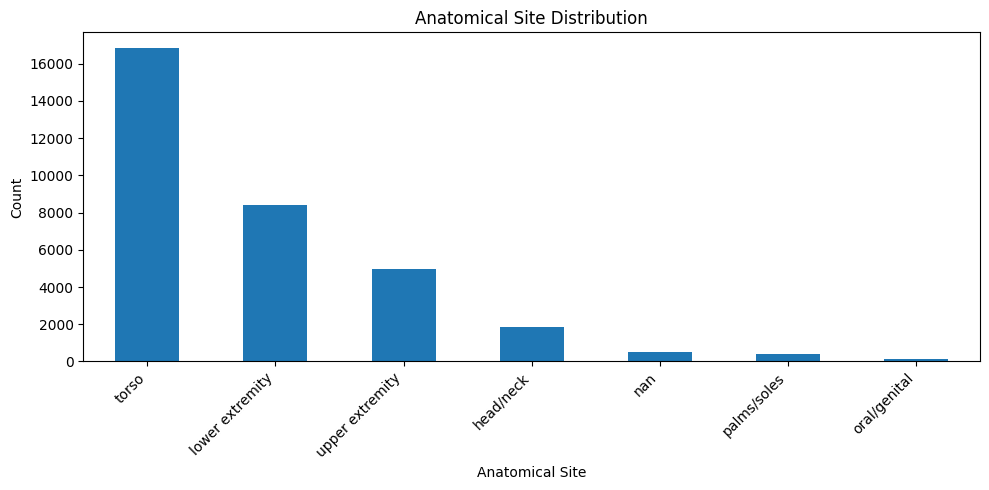

In [39]:
plt.figure(figsize=(10, 5))
df["anatom_site_general_challenge"].value_counts(dropna=False).plot(kind="bar")
plt.title("Anatomical Site Distribution")
plt.xlabel("Anatomical Site")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

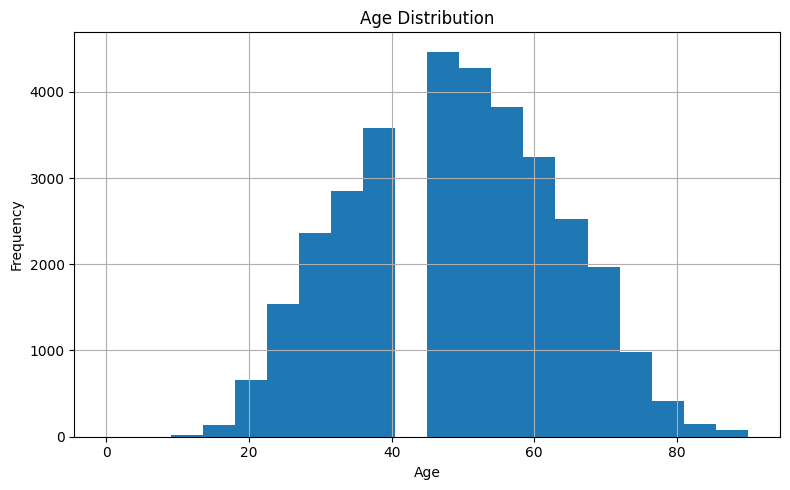

In [40]:
plt.figure(figsize=(8, 5))
df["age_approx"].dropna().hist(bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

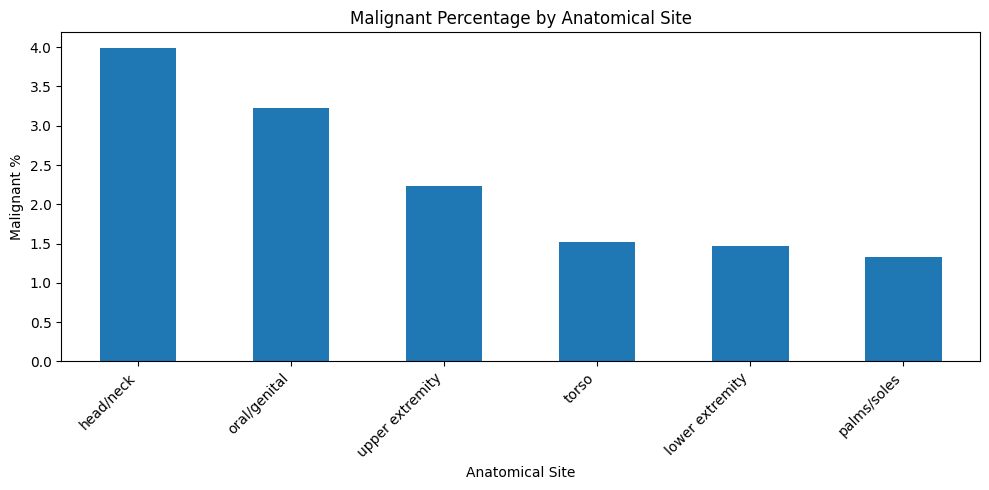

In [41]:
site_target_plot = pd.crosstab(
    df["anatom_site_general_challenge"], 
    df["target"], 
    normalize="index"
) * 100

site_target_plot = site_target_plot.rename(columns={0: "Benign %", 1: "Malignant %"})
site_target_plot = site_target_plot.sort_values("Malignant %", ascending=False)

plt.figure(figsize=(10, 5))
site_target_plot["Malignant %"].plot(kind="bar")
plt.title("Malignant Percentage by Anatomical Site")
plt.xlabel("Anatomical Site")
plt.ylabel("Malignant %")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [42]:
print("Updated EDA Summary")
print("===================")

print(f"1. The dataset contains {len(df):,} total rows and {df.shape[1]} columns.")
print(f"2. There are {df['patient_id'].nunique():,} unique patients represented in the dataset.")
print(f"3. The target variable is extremely imbalanced, with {benign_count:,} benign cases and {malignant_count:,} malignant cases.")
print(f"4. The benign-to-malignant ratio is approximately {benign_count / malignant_count:.2f}:1, which makes accuracy alone a poor evaluation metric.")
print(f"5. Age is mostly complete, with only {df['age_approx'].isna().sum():,} missing values.")
print(f"6. Sex and anatomical site also contain a small number of missing values that may need preprocessing if metadata is used.")
print(f"7. Most lesions are labeled as 'unknown' or 'nevus', while melanoma represents only a very small portion of the dataset.")
print(f"8. The most common anatomical site is torso, followed by lower extremity and upper extremity.")
print(f"9. Because multiple images belong to the same patient, train/validation/test splitting should be done at the patient level to reduce data leakage risk.")
print(f"10. Patients with both benign and malignant lesions: {patients_with_both_classes:,}. This makes patient-aware splitting especially important.")
print("11. Metadata such as age, sex, and anatomical site may contain predictive signal and could be useful in a multimodal model.")
print("12. Due to the severe class imbalance, future modeling should prioritize recall, F1-score, ROC-AUC, and sensitivity for malignant cases rather than overall accuracy.")

Updated EDA Summary
1. The dataset contains 33,126 total rows and 9 columns.
2. There are 2,056 unique patients represented in the dataset.
3. The target variable is extremely imbalanced, with 32,542 benign cases and 584 malignant cases.
4. The benign-to-malignant ratio is approximately 55.72:1, which makes accuracy alone a poor evaluation metric.
5. Age is mostly complete, with only 68 missing values.
6. Sex and anatomical site also contain a small number of missing values that may need preprocessing if metadata is used.
7. Most lesions are labeled as 'unknown' or 'nevus', while melanoma represents only a very small portion of the dataset.
8. The most common anatomical site is torso, followed by lower extremity and upper extremity.
9. Because multiple images belong to the same patient, train/validation/test splitting should be done at the patient level to reduce data leakage risk.
10. Patients with both benign and malignant lesions: 427. This makes patient-aware splitting especially i

## Conclusion

This exploratory analysis confirms that the ISIC 2020 dataset is large, clinically relevant, and highly imbalanced. The most important findings for our project are:

- melanoma cases are rare
- metadata is mostly complete but contains some missing values
- multiple images exist per patient
- patient-level splitting is important to avoid leakage
- evaluation metrics must focus on malignant-case performance, not just accuracy

These findings will directly inform our preprocessing, splitting strategy, model training, and evaluation pipeline for melanoma detection.